In [ ]:
# Colab setup: fetch the repository so kpspv_helper.py and ./figures/ resolve.
# Skipped when you already have the repo (running locally).
import os, sys
if 'google.colab' in sys.modules and not os.path.exists('kpspv_helper.py'):
    !git clone -q https://github.com/Oxford-eMat-Lab/semiconductor-characterisation.git
    %cd semiconductor-characterisation/KPSPV

# Kelvin Probe and Surface Photovoltage

A Kelvin probe measures a voltage between a vibrating metal plate and a
sample it never touches. That voltage is a **work function difference**.
On a semiconductor the work function is not a fixed material constant: it
contains a term set by the doping and a term set by however the bands are
bent at the surface. Shine light on the sample and the bands flatten, so
the change in the reading — the **surface photovoltage** — isolates the
surface term on its own.

That is the whole technique. It is contactless, needs no vacuum and no
sample preparation, and it is one of the few ways to watch what a surface
is doing electrically while you are doing something to it.

This notebook builds it up from first principles:

| Section | Question answered |
|---|---|
| 1-2 | What does the instrument read, and what is a work function? |
| 3 | Why do two connected materials develop a voltage across a gap? |
| 4-5 | How is that DC voltage turned into a measurable AC signal? |
| 6 | How do we get an absolute work function out of a difference? |
| 7-8 | What does a semiconductor surface add, and where does its charge go? |
| 9 | What does a dielectric film on top add? |
| 10-11 | What does light do, and what does SPV measure? |
| 12 | What does a charge sweep reveal about an interface? |
| 13 | What else can SPV measure — recombination and diffusion length? |
| 14 | What does the model assume, and where does it fail? |

<div align="center">
   <img src="./figures/fig_kpspv_setup.jpg" width="640">
</div>

Equations are numbered (1), (2), ... and referred to by those numbers
throughout. All physics functions live in
[`./kpspv_helper.py`](./kpspv_helper.py), so the notebook itself stays
short; that module's docstrings point back to these equation numbers.

Sources are cited as [[1]](#ref1), [[2]](#ref2), ... and listed in the
[References](#references) section at the end. Each entry carries a DOI.
The instrument sections follow the Kelvin-probe literature
[[1]](#ref1)[[2]](#ref2)[[3]](#ref3)[[4]](#ref4)[[5]](#ref5)[[6]](#ref6),
and the surface and photovoltage sections follow the standard reviews and
the dielectric-interface modelling literature
[[7]](#ref7)[[8]](#ref8)[[9]](#ref9)[[13]](#ref13)[[14]](#ref14).

!!! warning "Sign conventions"
    Both CPD and SPV are quoted with either sign in the literature. This
    notebook fixes one convention in Eq. (2) and Eq. (18) and holds to it
    everywhere, including in `kpspv_helper.py` and in every figure. If you
    compare a number here with one from a paper, check the paper's
    convention first — an inverted SPV turns an inverted surface into an
    accumulated one.

## 1. What does a Kelvin probe actually read?

Put a small metal plate a fraction of a millimetre above a sample. Connect
the two with a wire. Now measure the voltage you have to apply in that wire
to make the electric field in the gap vanish.

That voltage is typically a few hundred millivolts, and three things about
it are worth noticing straight away.

- **Nothing touches the sample.** There is a gap, so no current flows
  through the sample and nothing is scratched, contaminated or shorted.
- **No current flows at the measurement point either.** The reading is
  taken at the condition where the field, and therefore the charge on the
  plates, is zero. The instrument is a null detector, not an ammeter.
- **The number belongs to two surfaces, not one.** Change the probe and the
  reading changes. There is no way around this: the measurement is a
  difference, and turning it into an absolute number takes a separate
  calibration (Sec. 6).

The technique is Lord Kelvin's, from 1898 [[1]](#ref1). Zisman turned it
into a practical instrument by vibrating one plate [[2]](#ref2), and that
is still how it is done.

## 2. What is a work function, and what is it made of?

The work function is the energy needed to take an electron from the Fermi
level of a material to the vacuum level just outside its surface:

$$
\Phi = E_{\text{vac}} - E_F \tag{1}
$$

The phrase *just outside its surface* is doing real work in that sentence.
The relevant vacuum level is the **local** one, a few nanometres away —
close enough that the electron has escaped the material but not so far that
it has left the neighbourhood. That local vacuum level is set by whatever
dipole layer sits at the surface: adsorbed water, an oxide, a monolayer of
contamination. This is exactly why the work function is a *surface*
property, and why a Kelvin probe is sensitive to things that a bulk
measurement cannot see at all.

Typical metal values, in eV:

| Material | $\Phi$ (eV) |
|---|---|
| Pt | 5.65 |
| Ni | 5.15 |
| Au | 5.10 |
| Cu | 4.65 |
| HOPG (graphite) | 4.60 |
| W | 4.55 |
| stainless steel | 4.40 |
| Al | 4.28 |

Treat these as nominal. Reported values for the *same* metal spread over
100 meV or more, because they depend on crystal face and on what is
adsorbed on it. That spread is the floor on how well any Kelvin probe can
report an absolute work function, and it is not an instrument limitation.

## 3. Why do two connected materials develop a voltage between them?

Take two materials with different work functions, facing each other across
a gap, and connect them with a wire.

Electrons flow through the wire from the low-work-function material to the
high-work-function one until the Fermi levels line up — that is what
electrical contact means. But the charge that moved has to sit somewhere,
and the only place it can sit is on the two facing surfaces. The plates end
up equally and oppositely charged, and there is now a field in the gap.

The potential difference across that gap is the **contact potential
difference**:

$$
V_{\text{CPD}} = \frac{\Phi_{\text{sample}} - \Phi_{\text{probe}}}{q} \tag{2}
$$

<div align="center">
   <img src="./figures/fig_kpspv_bands_cpd.jpg" width="700">
</div>

**The sign convention used everywhere below.** The instrument applies a
backing voltage $V_b$ to the probe and finds the value that nulls the
signal; the contact potential difference is defined as
$V_{\text{CPD}} = -V_b(\text{null})$. With that definition Eq. (2) follows,
and a sample with a *higher* work function than the probe gives a
*positive* CPD.

The Fermi levels align, the vacuum levels do not — and it is the offset
between the vacuum levels that you measure. Note also what Eq. (2) does not
contain: no bulk property of either material, no thickness, no resistivity.
Only the two surfaces.

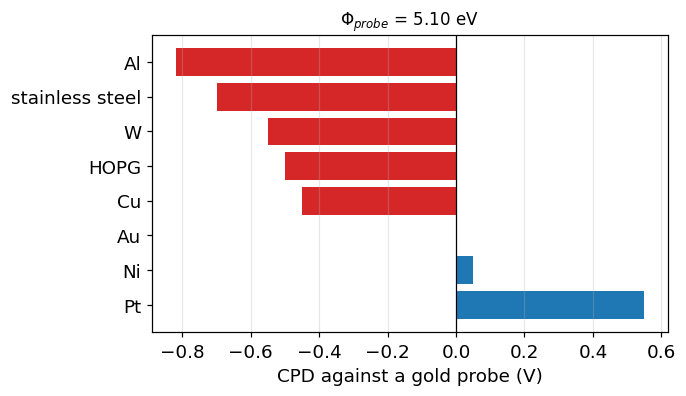

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import kpspv_helper as kp

plt.rcParams.update({'font.size': 12})

probe = kp.WORK_FUNCTION_EV['Au']            # a gold-coated probe tip
samples = ['Pt', 'Ni', 'Au', 'Cu', 'HOPG', 'W', 'stainless steel', 'Al']
phi = np.array([kp.WORK_FUNCTION_EV[s] for s in samples])
cpd = kp.cpd_from_work_functions(phi, probe)          # Eq. (2)

plt.figure(figsize=(6.4, 3.8))
colors = ['C0' if c >= 0 else 'C3' for c in cpd]
plt.barh(samples, cpd, color=colors)
plt.axvline(0, color='k', lw=0.8)
plt.xlabel('CPD against a gold probe (V)')
plt.title(f'$\\Phi_{{probe}}$ = {probe:.2f} eV', fontsize=11)
plt.grid(axis='x', alpha=0.3); plt.tight_layout(); plt.show()

Gold against a gold probe reads zero: the same material top and bottom, no
difference, no CPD. Everything else is measured relative to that. Swap the
probe for platinum and every bar in the plot shifts by the same amount —
the *shape* of the data is a property of the samples, the *offset* is a
property of the probe.

## 4. How does a vibrating capacitor turn that voltage into a current?

CPD is a DC voltage across a gap with no current flowing. There is nothing
to amplify. The trick, which is Zisman's [[2]](#ref2), is to make the gap
move.

If the probe vibrates, the capacitance between probe and sample becomes a
function of time:

$$
C(t) = \frac{\varepsilon_0 A}{d_0 + d_1\sin\omega t} \tag{3}
$$

with $d_0$ the mean spacing and $d_1$ the amplitude of the vibration. The
charge on a capacitor is $Q = CV$, so with $V$ fixed and $C$ moving, charge
has to flow in and out through the wire:

$$
i(t) = \left(V_b + V_{\text{CPD}}\right)\frac{dC}{dt} \tag{4}
$$

That is the entire measurement principle. A static potential difference has
been converted into an alternating current at a frequency *we* chose, which
can be amplified narrowband, phase-sensitively, far from the 1/f noise
floor. It is the same argument as the chopper and lock-in chain in the EQE
notebook, done mechanically.

The ratio $\varepsilon = d_1/d_0$ is the **modulation index**. Larger
$\varepsilon$ means more signal — and also a more distorted, harmonic-rich
current waveform, because $C(t)$ in Eq. (3) is not sinusoidal even when the
motion is [[4]](#ref4)[[6]](#ref6).

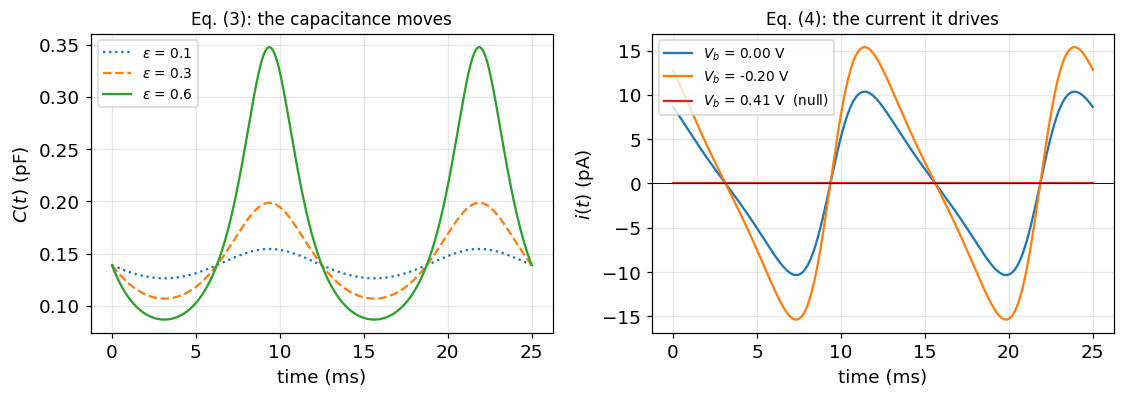

In [2]:
f = 80.0                                   # Hz, typical macro-scale probe
t = np.linspace(0, 2 / f, 800)
cpd_true = -0.412                          # V, the sample we are measuring

fig, ax = plt.subplots(1, 2, figsize=(10.4, 3.8))

for eps, ls in [(0.1, ':'), (0.3, '--'), (0.6, '-')]:
    C = kp.kelvin_capacitance(t, d0_um=200.0, d1_um=200 * eps, freq_Hz=f)
    ax[0].plot(t * 1e3, C * 1e12, ls, label=f'$\\varepsilon$ = {eps:.1f}')
ax[0].set_xlabel('time (ms)'); ax[0].set_ylabel('$C(t)$ (pF)')
ax[0].set_title('Eq. (3): the capacitance moves', fontsize=11)
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

for Vb, c in [(0.0, 'C0'), (-0.2, 'C1'), (-cpd_true, 'C3')]:
    i = kp.kelvin_current(t, Vb, cpd_true, d1_um=60.0, freq_Hz=f)
    lbl = f'$V_b$ = {Vb:.2f} V' + ('  (null)' if abs(Vb + cpd_true) < 1e-9 else '')
    ax[1].plot(t * 1e3, i * 1e12, color=c, label=lbl)
ax[1].axhline(0, color='k', lw=0.6)
ax[1].set_xlabel('time (ms)'); ax[1].set_ylabel('$i(t)$ (pA)')
ax[1].set_title('Eq. (4): the current it drives', fontsize=11)
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

Left: raising the modulation index raises the peak-to-peak capacitance
swing steeply, and visibly distorts it away from a sine — the spacing
appears in the *denominator* of Eq. (3), so the capacitance spikes as the
probe approaches and flattens as it retreats.

Right: the current scales with $(V_b + V_{\text{CPD}})$ and reverses phase
when that bracket changes sign. At $V_b = -V_{\text{CPD}}$ it is zero at
every instant, not just on average. That is the null.

## 5. Why is there a null, and why is it the worst place to measure?

The peak-to-peak signal that comes out of the preamplifier is linear in the
backing voltage:

$$
V_{ptp} = k\left(V_b + V_{\text{CPD}}\right) \tag{5}
$$

and vanishes at $V_b = -V_{\text{CPD}}$ [[4]](#ref4). The gradient $k$
depends on the probe area, the mean spacing, the vibration amplitude and
the amplifier gain. Every one of those drifts. **None of them moves the
zero crossing.** That is why the measured quantity is the crossing and not
the amplitude, and it is the single most important design fact about the
instrument.

There is a catch, and it is a serious one. The signal-to-noise ratio is
*worst* exactly where the signal is zero. Null-seeking feedback schemes
therefore operate on the smallest signal the instrument ever produces, and
a lock-in has no phase to lock to at the point where the phase inverts
[[4]](#ref4).

The resolution, due to Baikie, is the **off-null** method: measure at
backing voltages far enough from the null that the signal is comfortably
above the noise, and get the crossing by extrapolation
[[4]](#ref4)[[5]](#ref5).

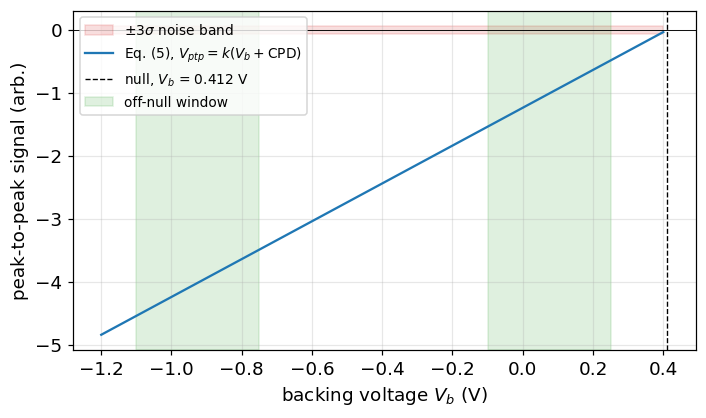

In [3]:
Vb = np.linspace(-1.2, 0.4, 400)
sig = kp.offnull_amplitude(Vb, cpd_true, gradient_V_per_V=3.0)   # Eq. (5)
noise = 0.02                                                     # V, rms

plt.figure(figsize=(6.6, 4.0))
plt.fill_between(Vb, -3 * noise, 3 * noise, color='C3', alpha=0.15,
                 label='$\\pm 3\\sigma$ noise band')
plt.plot(Vb, sig, color='C0', label='Eq. (5), $V_{ptp} = k(V_b + $CPD$)$')
plt.axvline(-cpd_true, ls='--', color='k', lw=0.9,
            label=f'null, $V_b$ = {-cpd_true:.3f} V')
plt.axhline(0, color='k', lw=0.6)
for lo, hi, lbl in [(-1.1, -0.75, 'off-null window'), (-0.1, 0.25, None)]:
    plt.axvspan(lo, hi, color='C2', alpha=0.15, label=lbl)
plt.xlabel('backing voltage $V_b$ (V)')
plt.ylabel('peak-to-peak signal (arb.)')
plt.legend(fontsize=9, loc='upper left'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

The signal is plotted *signed*: the instrument recovers the sign from the
phase of the current in Eq. (4), which inverts as $V_b$ passes through the
null. What a peak-to-peak detector actually returns is the magnitude, so
the measured curve is a V shape and the sign has to come from the phase —
and at the null there is no phase to measure.

The line crosses zero inside the noise band. Anywhere within roughly
$\pm 20$ mV of the null the instrument is measuring noise, which is why a
null-seeking servo parked there reports a number that wanders. The green
windows are where the measurement is actually made: the signal is tens of
times the noise there, and the crossing is recovered by fitting.

## 6. How is the null found, and how is an absolute work function obtained?

Fit a straight line to the off-null points and solve for the crossing:

$$
V_{ptp} = k\,V_b + c
\quad\Longrightarrow\quad
V_{\text{CPD}} = \frac{c}{k} \tag{6}
$$

The uncertainty on CPD needs the full fit covariance rather than the two
separate standard errors, because $k$ and $c$ are strongly correlated over
a limited sweep range and CPD is their ratio. `kp.fit_null_point` does
this.

The measurement still only gives a difference. To get the sample's own work
function, first measure a reference material whose work function you are
willing to assert, and use it to pin the probe:

$$
\Phi_{\text{sample}} = \Phi_{\text{probe}} + q\,V_{\text{CPD}},
\qquad
\Phi_{\text{probe}} = \Phi_{\text{ref}} - q\,V_{\text{CPD,ref}} \tag{7}
$$

Gold and freshly cleaved HOPG are the usual references.

Off-null Kelvin fit
-------------------
  fit        V_ptp = 2.998 * V_b + -1.237   (R^2 = 1.00000)
  gradient   k     = 2.998 +/- 0.0007 V/V
  contact p. CPD   = -412.8 +/- 0.23 mV

  true CPD = -412.0 mV


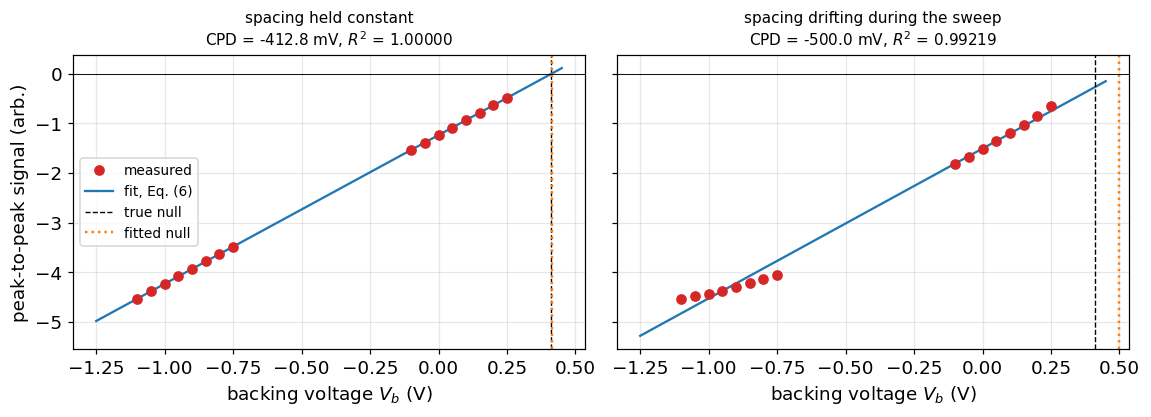

In [4]:
Vb_meas = np.concatenate([np.linspace(-1.10, -0.75, 8),
                          np.linspace(-0.10,  0.25, 8)])   # off-null only

clean = kp.synthetic_null_sweep(Vb_meas, cpd_true, noise_mV=2.0, seed=0)
drift = kp.synthetic_null_sweep(Vb_meas, cpd_true, noise_mV=2.0,
                                spacing_drift=0.35, seed=0)

fit_clean = kp.fit_null_point(Vb_meas, clean)     # Eq. (6)
fit_drift = kp.fit_null_point(Vb_meas, drift)
print(fit_clean.summary())
print(f"\n  true CPD = {cpd_true * 1e3:.1f} mV")

x = np.linspace(-1.25, 0.45, 50)
fig, ax = plt.subplots(1, 2, figsize=(10.6, 4.0), sharey=True)
for a, (y, fit, ttl) in zip(ax, [
        (clean, fit_clean, 'spacing held constant'),
        (drift, fit_drift, 'spacing drifting during the sweep')]):
    a.plot(Vb_meas, y, 'o', color='C3', zorder=3, label='measured')
    a.plot(x, fit.gradient * x + fit.gradient * fit.cpd_V, color='C0',
           label='fit, Eq. (6)')
    a.axvline(-cpd_true, ls='--', color='k', lw=0.9, label='true null')
    a.axvline(-fit.cpd_V, ls=':', color='C1', lw=1.6, label='fitted null')
    a.axhline(0, color='k', lw=0.6)
    a.set_xlabel('backing voltage $V_b$ (V)')
    a.set_title(f'{ttl}\nCPD = {fit.cpd_V*1e3:.1f} mV, '
                f'$R^2$ = {fit.r_squared:.5f}', fontsize=10)
    a.grid(alpha=0.3)
ax[0].set_ylabel('peak-to-peak signal (arb.)')
ax[0].legend(fontsize=9)
plt.tight_layout(); plt.show()

Left: the extraction works, and returns CPD to well under a millivolt from
points that were never taken anywhere near the null.

Right is the failure worth knowing about. The spacing was allowed to drift
by 35% during the sweep, which makes $V_{ptp}$ a curve rather than a line —
and a straight line fitted to a curve crosses zero in the wrong place. The
error here is 88 mV — a fifth of the value being measured — while $R^2$
only falls from 1.00000 to 0.992. **A fit that most people would call
excellent is hiding an error larger than everything the technique is
usually used to resolve.** The give-away is in the residuals if you look
for it: the low-$V_b$ points bend systematically off the line rather than
scattering about it. This is why real instruments regulate the tip-sample
spacing actively, using the fitted gradient $k$ itself as the height signal
[[4]](#ref4)[[6]](#ref6): $k$ is a function of $d_0$, so holding $k$
constant holds the spacing constant.

A steady but *wrong* spacing is harmless by comparison — it changes $k$ and
leaves the crossing exactly where it was. It is the drift *within* a sweep
that does the damage.

raw drift over 3 h        : +74.8 mV
residual after bracketing : +0.8 mV


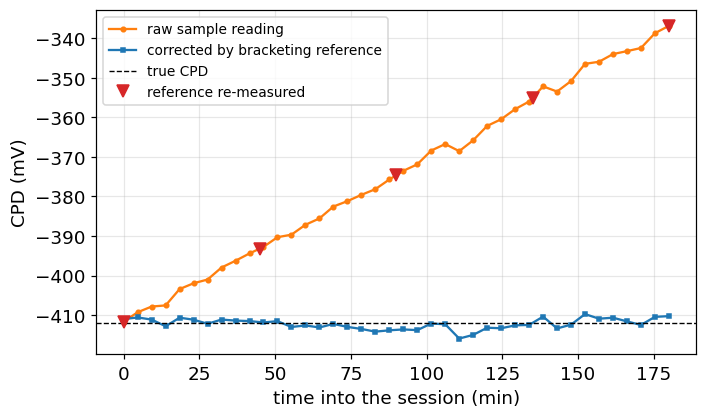

In [5]:
minutes = np.linspace(0, 180, 40)
reading = kp.synthetic_probe_drift(minutes, cpd_true,
                                   drift_mV_per_hour=25.0, seed=1)

# bracketing: re-measure the reference every 45 min and correct by it
t_ref = np.arange(0, 181, 45)
ref_drift = kp.synthetic_probe_drift(t_ref, 0.0, drift_mV_per_hour=25.0,
                                     noise_mV=1.0, seed=4)
corrected = reading - np.interp(minutes, t_ref, ref_drift)

plt.figure(figsize=(6.6, 4.0))
plt.plot(minutes, reading * 1e3, 'o-', ms=3, color='C1',
         label='raw sample reading')
plt.plot(minutes, corrected * 1e3, 's-', ms=3, color='C0',
         label='corrected by bracketing reference')
plt.axhline(cpd_true * 1e3, ls='--', color='k', lw=0.9, label='true CPD')
plt.plot(t_ref, np.interp(t_ref, minutes, reading) * 1e3, 'v', color='C3',
         ms=8, label='reference re-measured')
plt.xlabel('time into the session (min)'); plt.ylabel('CPD (mV)')
plt.legend(fontsize=9); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"raw drift over 3 h        : {(reading[-1]-reading[0])*1e3:+.1f} mV")
print(f"residual after bracketing : {(corrected[-1]-corrected[0])*1e3:+.1f} mV")

The probe work function is not a constant. It drifts as the tip picks up
adsorbates, at a rate of tens of millivolts per hour in ambient air, and
Eq. (7) passes that drift straight into every absolute work function you
report. Bracketing the sample between reference measurements removes almost
all of it.

This leaves a strong asymmetry, and it is the practical fact to take away
from the first half of this notebook:

| Quantity | Realistic accuracy | Why |
|---|---|---|
| **Relative** changes on one sample, one session | a few mV | the probe is the same probe; only $V_{\text{CPD}}$ moved |
| **Absolute** work function | $\sim 50$ meV or worse | Eq. (7) inherits the reference value, the probe drift, and the 100 meV spread in published reference work functions |

It is the same lesson as TLM's slope and intercept: the same fit, the same
data, and two extracted numbers with wildly different trustworthiness. Ask
what a Kelvin probe measurement is *for* before deciding which one you
need. Most of the time it is the relative number, which is the good one.

## 7. What does a semiconductor surface add?

Everything so far applies to two pieces of metal. A semiconductor is
different in one decisive way: **its work function is not a material
constant.**

At flat band it is built from three pieces — the electron affinity, the
half gap, and how far the Fermi level sits from mid-gap:

$$
\Phi_s = \chi + \frac{E_g}{2} - q\phi_F \tag{8}
$$

$$
\phi_F = \frac{kT}{q}\ln\!\left(\frac{N_{\text{dop}}}{n_i}\right) \tag{9}
$$

with $\phi_F$ taken positive for n-type and negative for p-type
[[9]](#ref9)[[10]](#ref10). So the doping alone moves the work function of
silicon over most of a volt.

But the bands need not be flat at the surface, and in practice they never
are. Adding the band bending $\phi_s$ and any potential $V_i$ dropped
across a film on top, the reading of Eq. (2) generalises to the equation
the rest of this notebook is about:

$$
V_{\text{CPD}} = -\left(\frac{\Phi_{ms}}{q} + \phi_s + V_i\right) \tag{10}
$$

where $\Phi_{ms} = \Phi_{\text{probe}} - \Phi_s$ is the flat-band work
function difference in eV [[9]](#ref9).

Read Eq. (10) carefully, because it sets up the rest of the notebook. **One
measurement returns one number containing three unknowns.** No single CPD
reading can separate the probe, the doping, the band bending and the film
charge. Separating them is what Secs. 10-13 are for.

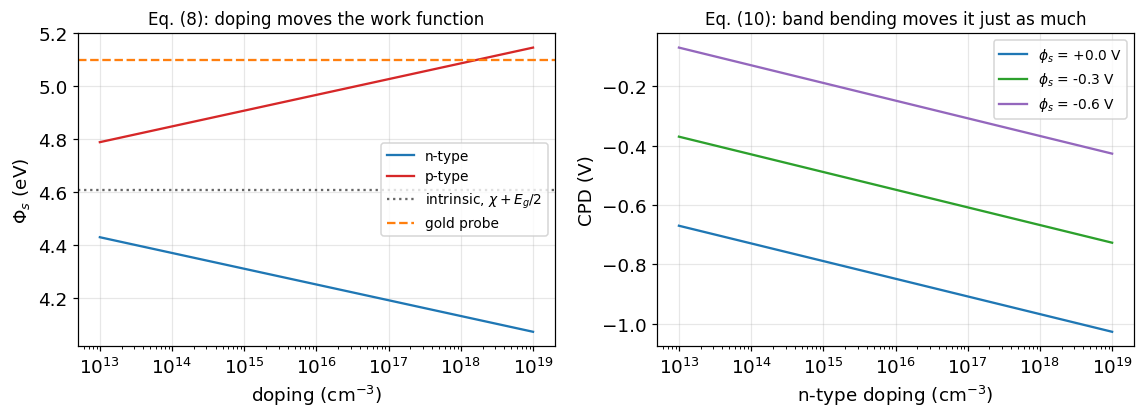

In [6]:
N = np.logspace(13, 19, 200)
phi_n = kp.work_function_semiconductor(N, 'n')     # Eq. (8)
phi_p = kp.work_function_semiconductor(N, 'p')

fig, ax = plt.subplots(1, 2, figsize=(10.6, 4.0))
ax[0].semilogx(N, phi_n, color='C0', label='n-type')
ax[0].semilogx(N, phi_p, color='C3', label='p-type')
ax[0].axhline(kp.CHI_SI_EV + kp.EG_SI_EV / 2, ls=':', color='0.4',
              label='intrinsic, $\\chi + E_g/2$')
ax[0].axhline(kp.WORK_FUNCTION_EV['Au'], ls='--', color='C1',
              label='gold probe')
ax[0].set_xlabel('doping (cm$^{-3}$)'); ax[0].set_ylabel('$\\Phi_s$ (eV)')
ax[0].set_title('Eq. (8): doping moves the work function', fontsize=11)
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

# how much band bending is worth, on the same axis
for phi_s, c in [(0.0, 'C0'), (-0.3, 'C2'), (-0.6, 'C4')]:
    ax[1].semilogx(N, kp.cpd(phi_s, doping_cm3=N, dopant_type='n'), color=c,
                   label=f'$\\phi_s$ = {phi_s:+.1f} V')
ax[1].set_xlabel('n-type doping (cm$^{-3}$)'); ax[1].set_ylabel('CPD (V)')
ax[1].set_title('Eq. (10): band bending moves it just as much', fontsize=11)
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

Left: each branch moves by about 0.36 eV over six decades of doping, and
n-type and p-type silicon differ by up to about 1.1 eV at the same doping.
Heavily doped p-type crosses the gold probe value near $2\times10^{18}$
cm$^{-3}$, where the CPD of Eq. (2) would read zero — and where a Kelvin
probe would be at its least useful.

Right is the point of the section. Bending the bands by 0.6 V shifts the
CPD by 0.6 V, which is *larger* than the entire six-decade doping range of
one branch on the left. And a few hundred millivolts of band bending is
what a fairly modest surface charge produces (Sec. 8). So on a
semiconductor it is the surface, not the bulk, that dominates a Kelvin
probe reading — which is exactly why the technique is used on surfaces.

## 8. Where does the surface charge go?

Put a sheet of charge on the surface. The semiconductor has to mirror it,
and it has three ways to do so: uncover ionised dopants, pile up majority
carriers, or invert and pile up minority carriers. Which one happens is
what the band bending $\phi_s$ decides.

The carrier densities at the surface follow the bending exponentially:

$$
n_s = n_b\,e^{+\phi_s/V_t},
\qquad
p_s = p_b\,e^{-\phi_s/V_t},
\qquad
V_t = kT/q \tag{11}
$$

so on n-type material $\phi_s > 0$ means **accumulation** and
$\phi_s < 0$ means depletion and then **inversion**.

Integrating Poisson's equation once through the space-charge region gives
the charge the semiconductor holds per unit area [[10]](#ref10):

$$
Q_{sc} = -\,\text{sign}(\phi_s)\sqrt{2q\varepsilon_s V_t\,G(\phi_s)},
\qquad
G = n_b\!\left(e^{u}-1-u\right) + p_b\!\left(e^{-u}-1+u\right) \tag{12}
$$

with $u = \phi_s/V_t$. $G$ is positive for either sign of $u$, so $Q_{sc}$
always opposes $\phi_s$ — as it must.

Eq. (12) covers accumulation, depletion and inversion in one expression.
The familiar depletion-approximation result is the special case where only
the ionised dopants matter:

$$
|\phi_s| \approx \frac{q N^2}{2\varepsilon_s N_{\text{dop}}}
= 9.05\times10^{-7}\,\frac{N^2}{K_s N_{\text{dop}}}\ \text{V} \tag{13}
$$

with $N$ the mirrored charge in cm$^{-2}$ [[7]](#ref7). Useful for a
back-of-envelope estimate, and worth knowing where it breaks.

<div align="center">
   <img src="./figures/fig_kpspv_surface_bands.jpg" width="700">
</div>

phi_s = -0.20 V : exact 1.061e+11, depletion 1.137e+11 cm^-2  (+7.2%)
phi_s = -0.35 V : exact 1.448e+11, depletion 1.504e+11 cm^-2  (+3.9%)
phi_s = -0.50 V : exact 1.751e+11, depletion 1.798e+11 cm^-2  (+2.7%)


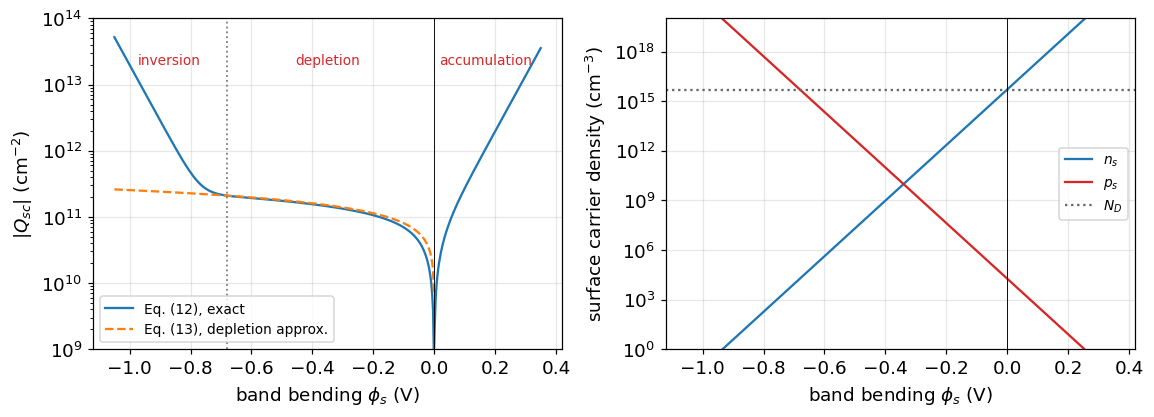

In [7]:
Nd = 5e15                                  # cm^-3, n-type
phi_s = np.linspace(-1.05, 0.35, 500)
Q = kp.space_charge_density(phi_s, Nd, 'n')                    # Eq. (12)

Vt = kp.thermal_voltage()
depl = np.sqrt(2 * kp.K_SI * kp.EPS0 * kp.Q * Nd
               * np.clip(-phi_s, 0, None)) / kp.Q              # Eq. (13)

fig, ax = plt.subplots(1, 2, figsize=(10.6, 4.0))
ax[0].semilogy(phi_s, np.abs(Q), color='C0', label='Eq. (12), exact')
ax[0].semilogy(phi_s[phi_s < 0], depl[phi_s < 0], '--', color='C1',
               label='Eq. (13), depletion approx.')
ax[0].axvline(0, color='k', lw=0.6)
ax[0].text(0.17, 2e13, 'accumulation', fontsize=9, ha='center', color='C3')
ax[0].text(-0.35, 2e13, 'depletion', fontsize=9, ha='center', color='C3')
ax[0].text(-0.87, 2e13, 'inversion', fontsize=9, ha='center', color='C3')
ax[0].axvline(-2 * kp.fermi_potential(Nd, 'n'), ls=':', color='0.5', lw=1.2)
ax[0].set_xlabel('band bending $\\phi_s$ (V)')
ax[0].set_ylabel('$|Q_{sc}|$ (cm$^{-2}$)')
ax[0].set_ylim(1e9, 1e14)
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

n_b, p_b = kp.bulk_carrier_densities(Nd, 'n')
n_s, p_s = kp.surface_carrier_densities(phi_s, n_b, p_b)       # Eq. (11)
ax[1].semilogy(phi_s, n_s, color='C0', label='$n_s$')
ax[1].semilogy(phi_s, p_s, color='C3', label='$p_s$')
ax[1].axhline(Nd, ls=':', color='0.4', label='$N_D$')
ax[1].axvline(0, color='k', lw=0.6)
ax[1].set_xlabel('band bending $\\phi_s$ (V)')
ax[1].set_ylabel('surface carrier density (cm$^{-3}$)')
ax[1].set_ylim(1e0, 1e20)
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

for p in (-0.20, -0.35, -0.50):
    q_ex = abs(kp.space_charge_density(p, Nd, 'n'))
    q_dp = np.sqrt(2 * kp.K_SI * kp.EPS0 * kp.Q * Nd * abs(p)) / kp.Q
    print(f"phi_s = {p:+.2f} V : exact {q_ex:.3e}, depletion {q_dp:.3e} "
          f"cm^-2  ({100*(q_dp/q_ex-1):+.1f}%)")

Three things to read off these panels.

**The depletion approximation overestimates, by a fixed amount.** The
dashed line sits above the exact curve everywhere, and the discrepancy is
exactly one thermal voltage: Eq. (12) in depletion reduces to Eq. (13) with
$|\phi_s| - kT/q$ in place of $|\phi_s|$. At 200 mV of bending that is a 7%
error in the charge; at 500 mV it is under 3%. Small, but systematic, and
it is not noise.

**Both approximations fail at the ends.** In accumulation
($\phi_s > 0$) the dashed curve does not exist at all — Eq. (13) has
nothing to say, because the charge is majority carriers, not dopants. And
past the dotted line at $\phi_s = -2\phi_F \approx -0.68$ V the exact
curve peels sharply upward: the surface has inverted and the charge is now
minority carriers. Neither region is depletion, and using Eq. (13) there
gives an answer that is simply wrong rather than slightly off.

**The exponential is brutal.** In the right panel, 0.35 V of bending moves
the surface electron density by six decades. It is the reason a modest
sheet charge bends the bands so far, and — jumping ahead to Sec. 13 — the
reason band bending is such an effective way to suppress recombination.

## 9. What does a dielectric film on top add?

Real samples are rarely bare. A passivating oxide, a nitride or an alumina
film sits on the surface, and that film carries charge of its own. Two new
terms appear.

**Charge in the film.** An effective sheet density $Q_f$ sitting a distance
$x_c$ from the interface — the **centroid** — drops a potential across the
film [[9]](#ref9)[[11]](#ref11):

$$
V_i = \frac{x_c\,Q_f}{K_i\varepsilon_0} \tag{14}
$$

Only the product $x_c Q_f$ is observable. A Kelvin probe cannot tell a
small charge far from the interface from a large one close to it, and that
ambiguity is real, not a limitation of this model.

**Charge in interface states.** The lattice stops at the interface, leaving
states in the gap. Those in the lower half behave as donors — positive when
empty of electrons — and those in the upper half as acceptors, negative
when full [[9]](#ref9)[[13]](#ref13)[[14]](#ref14):

$$
Q_{it} = \int_{E_v}^{E_i} D_{it}^{d}(E)\,f_p(E)\,dE
       - \int_{E_i}^{E_c} D_{it}^{a}(E)\,f_n(E)\,dE \tag{15}
$$

with the occupancy from Shockley-Read-Hall statistics [[22]](#ref22),
evaluated with the **surface** carrier densities of Eq. (11):

$$
f_p = \frac{(\sigma_n/\sigma_p)\,n_1 + p_s}
           {(\sigma_n/\sigma_p)(n_s + n_1) + (p_s + p_1)},
\qquad f_n = 1 - f_p \tag{16}
$$

Because $f_p$ depends on $n_s$ and $p_s$, which depend on $\phi_s$, the
interface charge *moves as the bands bend*. That feedback is the whole
reason the curves in the next section have the shape they do.

Everything now has to balance. The film charge, the interface charge and
the space charge must sum to zero, and the only free variable is $\phi_s$:

$$
Q_f + Q_{sc}(\phi_s) + Q_{it}(\phi_s) = 0 \tag{17}
$$

`kp.solve_surface_potential` solves Eq. (17) by bisection, then Eq. (10)
turns the answer into a CPD.

Q_f = 0, no interface states : phi_s =   -0.000 mV
Q_f = 0, with interface states: phi_s =  -50.704 mV


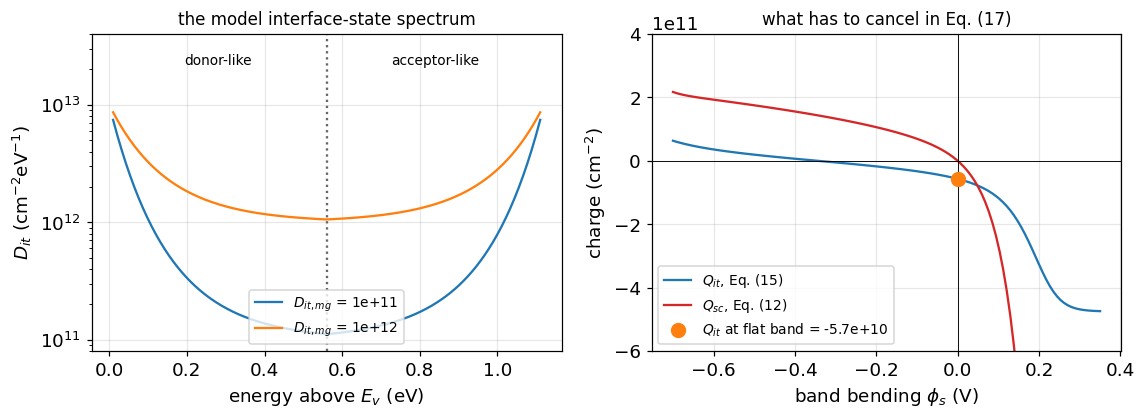

In [8]:
E = np.linspace(0.01, kp.EG_SI_EV - 0.01, 300)
fig, ax = plt.subplots(1, 2, figsize=(10.6, 4.0))

for dmg, c in [(1e11, 'C0'), (1e12, 'C1')]:
    ax[0].semilogy(E, kp.dit_profile(E, dit_midgap=dmg), color=c,
                   label=f'$D_{{it,mg}}$ = {dmg:.0e}')
ax[0].axvline(kp.EG_SI_EV / 2, ls=':', color='0.4')
ax[0].set_ylim(8e10, 4e13)
ax[0].text(0.28, 2.2e13, 'donor-like', fontsize=9, ha='center')
ax[0].text(0.84, 2.2e13, 'acceptor-like', fontsize=9, ha='center')
ax[0].set_xlabel('energy above $E_v$ (eV)')
ax[0].set_ylabel('$D_{it}$ (cm$^{-2}$eV$^{-1}$)')
ax[0].set_title('the model interface-state spectrum', fontsize=11)
ax[0].legend(fontsize=9, loc='lower center'); ax[0].grid(alpha=0.3)

ps = np.linspace(-0.7, 0.35, 120)
ax[1].plot(ps, [kp.interface_charge(p, Nd, 'n') for p in ps], color='C0',
           label='$Q_{it}$, Eq. (15)')
ax[1].plot(ps, kp.space_charge_density(ps, Nd, 'n'), color='C3',
           label='$Q_{sc}$, Eq. (12)')
ax[1].axhline(0, color='k', lw=0.6); ax[1].axvline(0, color='k', lw=0.6)
ax[1].set_xlabel('band bending $\\phi_s$ (V)')
ax[1].set_ylabel('charge (cm$^{-2}$)')
q_flat = kp.interface_charge(0.0, Nd, 'n')
ax[1].plot([0], [q_flat], 'o', color='C1', ms=9, zorder=4,
           label=f'$Q_{{it}}$ at flat band = {q_flat:.1e}')
ax[1].set_ylim(-6e11, 4e11)
ax[1].set_title('what has to cancel in Eq. (17)', fontsize=11)
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

phi_ideal = kp.solve_surface_potential(0.0, Nd, 'n', dit_midgap=1e-30,
                                       dit_edge=1e-30)
phi_real = kp.solve_surface_potential(0.0, Nd, 'n')
print(f"Q_f = 0, no interface states : phi_s = {phi_ideal*1e3:+8.3f} mV")
print(f"Q_f = 0, with interface states: phi_s = {phi_real*1e3:+8.3f} mV")

The U-shaped $D_{it}$ on the left — flat through mid-gap, rising into band
tails at both edges — is the shape reported for the Si/SiO$_2$ interface
[[23]](#ref23). It is a model shape here, not a measured spectrum.

The right panel is Eq. (17) drawn as two curves that have to cancel against
whatever $Q_f$ is. Notice that $Q_{it}$ does not pass through zero at flat
band. On n-type material the Fermi level sits high in the gap, so the
acceptor-like states are largely filled and the interface carries net
negative charge even when the film carries none.

The printed numbers make that concrete: **a perfectly uncharged dielectric
still leaves about 50 mV of band bending**, purely because the interface
states are not neutral. Any interpretation that assumes flat band on an
uncharged film is already 50 mV out before anything else goes wrong.

## 10. What happens when the light comes on?

Illuminate the sample with above-gap light. The effect was first seen
on germanium by Brattain and Bardeen [[12]](#ref12). Electron-hole pairs are
generated, the excess carriers raise both $n_b$ and $p_b$ in Eq. (11), and
the semiconductor no longer needs to bend its bands so far to mirror the
same fixed film charge. **The bands flatten.**

The change in the reading is the surface photovoltage:

$$
V_{\text{SPV}} = V_{\text{CPD, dark}} - V_{\text{CPD, light}} \tag{18}
$$

This definition matters more than it looks. SPV is a *difference of two
differences*, taken with the same probe minutes apart. Look at what drops
out of Eq. (10) when you subtract: the probe work function, the
calibration, the semiconductor's doping term, and the film term $V_i$ —
all of them are identical in the two measurements and cancel exactly. What
survives is the band bending and nothing else:

$$
V_{\text{SPV}} = -\left(\phi_s^{\text{dark}} - \phi_s^{\text{light}}\right) \tag{19}
$$

So the fragile, calibration-dependent absolute measurement of Sec. 6 is not
needed at all for SPV. This is why the two halves of this technique belong
in one notebook: the Kelvin probe's weakness is precisely what SPV is
immune to.

<div align="center">
   <img src="./figures/fig_kpspv_spv_bands.jpg" width="700">
</div>

The sign then tells you which way the bands were bent in the dark, and
therefore the sign of the net surface charge. For **n-type** silicon:

| Film charge $Q_f$ | $\phi_s$ (dark) | Surface condition | $V_{\text{SPV}}$ |
|---|---|---|---|
| positive | $> 0$ | accumulation | negative |
| $\approx 0$ | $\approx 0$ | flat band | $\approx 0$ |
| negative, small | $< 0$ | depletion | positive |
| negative, large | $\ll 0$ | inversion | large positive |

On p-type material every sign in that table flips. This is the one place
where getting the convention wrong turns an inverted surface into an
accumulated one, so check it against Eq. (2) and Eq. (18) rather than
against memory.

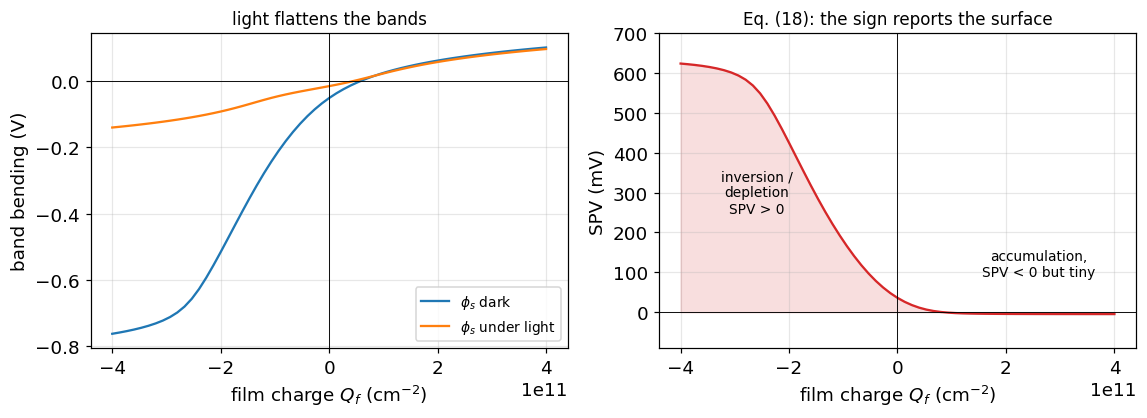

In [9]:
dn_light = 1e15                              # cm^-3 under the SPV lamp
Qf_scan = np.linspace(-4e11, 4e11, 61)

rows = [kp.cpd_dark_and_light(q, dn_light, Nd, 'n', xc_nm=5.0)
        for q in Qf_scan]
cpd_d = np.array([r[0] for r in rows])
cpd_l = np.array([r[1] for r in rows])
spv = np.array([r[2] for r in rows])
phid = np.array([r[3] for r in rows])
phil = np.array([r[4] for r in rows])

fig, ax = plt.subplots(1, 2, figsize=(10.6, 4.0))
ax[0].plot(Qf_scan, phid, color='C0', label='$\\phi_s$ dark')
ax[0].plot(Qf_scan, phil, color='C1', label='$\\phi_s$ under light')
ax[0].axhline(0, color='k', lw=0.6); ax[0].axvline(0, color='k', lw=0.6)
ax[0].set_xlabel('film charge $Q_f$ (cm$^{-2}$)')
ax[0].set_ylabel('band bending (V)')
ax[0].set_title('light flattens the bands', fontsize=11)
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

ax[1].plot(Qf_scan, spv * 1e3, color='C3')
ax[1].axhline(0, color='k', lw=0.6); ax[1].axvline(0, color='k', lw=0.6)
ax[1].fill_between(Qf_scan, 0, spv * 1e3, where=spv > 0, color='C3',
                   alpha=0.15)
ax[1].fill_between(Qf_scan, 0, spv * 1e3, where=spv < 0, color='C0',
                   alpha=0.15)
ax[1].text(-2.6e11, 250, 'inversion /\ndepletion\nSPV > 0', fontsize=9,
           ha='center')
ax[1].text(2.6e11, 90, 'accumulation,\nSPV < 0 but tiny', fontsize=9,
           ha='center')
ax[1].set_ylim(-90, 700)
ax[1].set_xlabel('film charge $Q_f$ (cm$^{-2}$)')
ax[1].set_ylabel('SPV (mV)')
ax[1].set_title('Eq. (18): the sign reports the surface', fontsize=11)
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

The left panel is Eq. (19) drawn directly: the light curve is squeezed
towards zero everywhere, and the gap between the two curves *is* the SPV.

The right panel is what you would actually plot from measurements. It
crosses zero close to $Q_f = 0$ — close, but not at it, for the interface
state reason of Sec. 9 — and its sign changes from negative in accumulation
to positive in depletion and inversion. The magnitude is strongly
asymmetric: at this lamp intensity the inverted side gives over 400 mV and
the accumulated side gives about 4 mV. Two separate effects stack up, and
both come from Eq. (12). Accumulating majority carriers screens the film
charge cheaply, so there is less bending to remove in the first place. And
the bending that *is* there is hard to remove, because the surface electron
density is already of order $N_D$ and an injected $\Delta n$ well below
$N_D$ barely changes it. Sec. 11 makes that second effect explicit.

The practical consequence: **SPV is a sensitive probe of a depleted or
inverted surface and a poor one of an accumulated surface.** For n-type
silicon that means SPV is at its best on exactly the films that matter most
for passivation — the negatively charged ones, alumina above all
[[20]](#ref20).

## 11. Why does SPV saturate, and what does the saturated value mean?

Turn the light up. As the injected carrier density rises, the surface needs
less and less bending, and in the limit the bands go completely flat. So
from Eq. (19), at full saturation:

$$
V_{\text{SPV}}(\Delta n \to \infty) = -\phi_s^{\text{dark}} \tag{20}
$$

which is the measurement everybody actually wants: **the saturated SPV is
the dark band bending.** From it, Eq. (13) gives the surface charge, and
Eq. (14) gives the film charge if you know the centroid.

The catch is the word *saturated*.

   Delta n                  inverted               accumulated
     1e+14    +373.2 mV ( 72.3% sat.)      -0.5 mV (  0.7% sat.)
     1e+15    +424.9 mV ( 82.3% sat.)      -4.2 mV (  6.8% sat.)
     1e+16    +471.2 mV ( 91.2% sat.)     -22.6 mV ( 36.2% sat.)
     1e+17    +498.5 mV ( 96.5% sat.)     -45.0 mV ( 72.0% sat.)
     1e+19    +514.1 mV ( 99.5% sat.)     -60.2 mV ( 96.2% sat.)


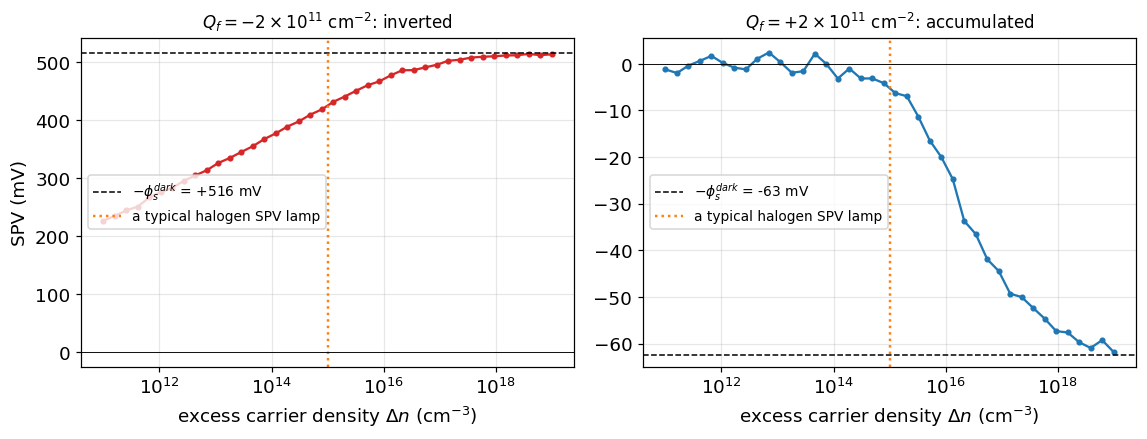

In [10]:
dn = np.logspace(11, 19, 40)
spv_inv = kp.synthetic_spv_intensity(dn, -2e11, Nd, 'n', noise_mV=1.5, seed=2)
spv_acc = kp.synthetic_spv_intensity(dn, +2e11, Nd, 'n', noise_mV=1.5, seed=5)

phi_dark_inv = kp.solve_surface_potential(-2e11, Nd, 'n')
phi_dark_acc = kp.solve_surface_potential(+2e11, Nd, 'n')

fig, ax = plt.subplots(1, 2, figsize=(10.6, 4.2))
panels = [(ax[0], spv_inv, -phi_dark_inv, 'C3',
           '$Q_f = -2\\times10^{11}$ cm$^{-2}$: inverted'),
          (ax[1], spv_acc, -phi_dark_acc, 'C0',
           '$Q_f = +2\\times10^{11}$ cm$^{-2}$: accumulated')]
for a, arr, sat, c, ttl in panels:
    a.semilogx(dn, arr * 1e3, 'o-', ms=3, color=c)
    a.axhline(sat * 1e3, ls='--', color='k', lw=1.0,
              label=f'$-\\phi_s^{{dark}}$ = {sat*1e3:+.0f} mV')
    a.axvline(1e15, ls=':', color='C1', lw=1.6,
              label='a typical halogen SPV lamp')
    a.axhline(0, color='k', lw=0.6)
    a.set_xlabel('excess carrier density $\\Delta n$ (cm$^{-3}$)')
    a.set_title(ttl, fontsize=11)
    a.legend(fontsize=9, loc='center left'); a.grid(alpha=0.3)
ax[0].set_ylabel('SPV (mV)')
plt.tight_layout(); plt.show()

print(f"{'Delta n':>10}  {'inverted':>24}  {'accumulated':>24}")
for d in (1e14, 1e15, 1e16, 1e17, 1e19):
    u = kp.cpd_dark_and_light(-2e11, d, Nd, 'n')[2]
    v = kp.cpd_dark_and_light(+2e11, d, Nd, 'n')[2]
    print(f"{d:10.0e}  {u*1e3:+8.1f} mV ({100*u/-phi_dark_inv:5.1f}% sat.)"
          f"  {v*1e3:+8.1f} mV ({100*v/-phi_dark_acc:5.1f}% sat.)")

This is the trap, and it is the most common way an SPV measurement gets
over-interpreted. **Neither curve is saturated at a realistic lamp
intensity, and the two are nowhere near each other.**

At $\Delta n = 10^{15}$ cm$^{-3}$ — about what a bright halogen fibre
source delivers [[9]](#ref9) — the inverted surface has reached roughly
80% of its saturation value, so reading the SPV as band bending
under-reports it by a fifth. The accumulated surface has reached under
10%, and reading *that* as band bending is wrong by an order of magnitude.

There is a second thing to notice in the right-hand panel. Below
$\Delta n \approx 10^{15}$ cm$^{-3}$ the accumulated trace is not a curve
at all — it is the 1.5 mV measurement noise. In accumulation the signal
does not merely under-report the band bending; for much of the useful
intensity range it is not distinguishable from zero.

The reason for the difference is Eq. (11) again. Flattening an inverted
surface means overwhelming a minority carrier density that started at
$p_b \approx 2\times10^{4}$ cm$^{-3}$, so even weak light does something.
Flattening an accumulated surface means overwhelming a majority carrier
density that started at $N_D = 5\times10^{15}$ cm$^{-3}$, so almost
nothing happens until $\Delta n$ approaches $N_D$.

Three rules follow, and they are the practical content of this section:

1. **Sweep the intensity.** A single-intensity SPV is only interpretable as
   band bending once you have shown the curve has gone flat. Assert it
   instead and you will be wrong, and wrong low.
2. **Do not transfer a lamp calibration between samples.** The injection
   needed for saturation is set by the surface being measured, not by the
   lamp.
3. **Be most suspicious in accumulation.** It is the regime where SPV is
   both smallest and furthest from saturation, and where the temptation to
   read a small number as "nearly flat band" is strongest.

## 12. What does a charge sweep reveal?

The single most informative KP/SPV experiment is not a single reading. It
is a **sweep of the surface charge** — usually by depositing ions onto the
film with a corona source, a few $10^{10}$ cm$^{-2}$ at a time, measuring
CPD in the dark and under light after each step
[[7]](#ref7)[[9]](#ref9)[[11]](#ref11).

Each of the three terms in Eq. (10) responds differently to $Q_f$, so the
shape of the resulting curve separates them.

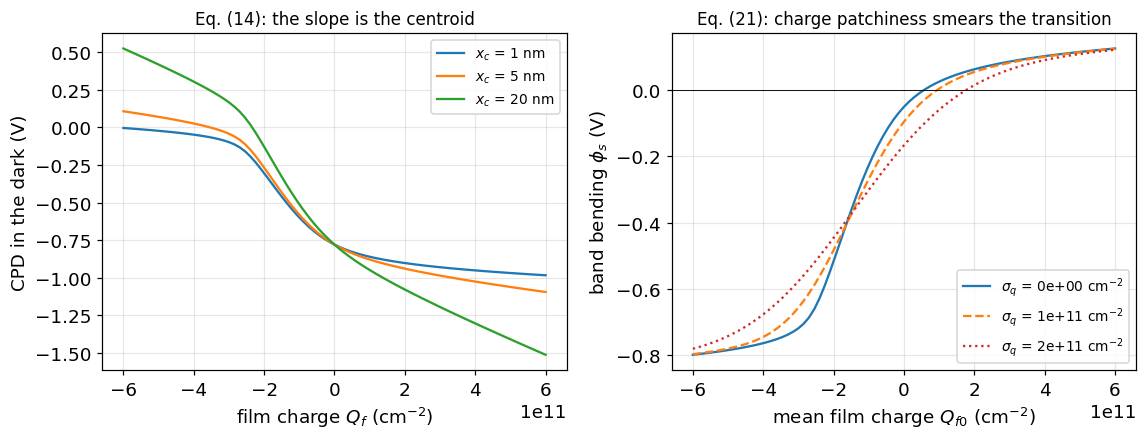

In [11]:
Qf = np.linspace(-6e11, 6e11, 81)

fig, ax = plt.subplots(1, 2, figsize=(10.6, 4.2))

for xc, c in [(1.0, 'C0'), (5.0, 'C1'), (20.0, 'C2')]:
    y = [kp.cpd_dark_and_light(q, dn_light, Nd, 'n', xc_nm=xc)[0] for q in Qf]
    ax[0].plot(Qf, y, color=c, label=f'$x_c$ = {xc:.0f} nm')
ax[0].set_xlabel('film charge $Q_f$ (cm$^{-2}$)')
ax[0].set_ylabel('CPD in the dark (V)')
ax[0].set_title('Eq. (14): the slope is the centroid', fontsize=11)
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

sharp = np.array([kp.solve_surface_potential(q, Nd, 'n') for q in Qf])
for sig, c, ls in [(0.0, 'C0', '-'), (1e11, 'C1', '--'), (2e11, 'C3', ':')]:
    f = lambda q: kp.solve_surface_potential(q, Nd, 'n')
    y = [kp.charge_fluctuation_average(q, sig, f) for q in Qf]
    ax[1].plot(Qf, y, ls, color=c,
               label=f'$\\sigma_q$ = {sig:.0e} cm$^{{-2}}$')
ax[1].axhline(0, color='k', lw=0.6)
ax[1].set_xlabel('mean film charge $Q_{f0}$ (cm$^{-2}$)')
ax[1].set_ylabel('band bending $\\phi_s$ (V)')
ax[1].set_title('Eq. (21): charge patchiness smears the transition',
                fontsize=11)
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**The straight parts give the centroid.** Once the surface is firmly
accumulated or firmly inverted, $\phi_s$ stops moving and all further
charge goes into $V_i$. The CPD then becomes a straight line in $Q_f$ whose
slope is $x_c/(K_i\varepsilon_0)$ from Eq. (14). Corona charging onto the
*outer* surface of a thick film gives a steep line; charge built into the
film near the interface gives an almost flat one. In the left panel a 20 nm
centroid produces several volts of swing while a 1 nm centroid produces
almost none — which is why corona experiments are easy to run and internal
film charge is hard to see.

**The transition region gives the interface.** The rounded step between the
two straight sections is where $\phi_s$ is doing the work. Its width along
the charge axis is set by $D_{it}$: more interface states means more charge
absorbed by Eq. (15) before the bands move, so the step stretches out.

**The width is not all $D_{it}$, though.** The right panel adds a Gaussian
spread $\sigma_q$ to the film charge and averages over it, Eq. (21):

$$
\langle X\rangle = \frac{\int X(Q_f)\,
  e^{-(Q_f - Q_{f0})^2/2\sigma_q^2}\,dQ_f}
  {\int e^{-(Q_f - Q_{f0})^2/2\sigma_q^2}\,dQ_f} \tag{21}
$$

Real films are not uniformly charged, and a millimetre-scale probe averages
over the patchwork [[17]](#ref17). The result looks *exactly* like a higher
interface-state density. A fit that assumes a uniform surface will
therefore over-report $D_{it}$, and there is no way to tell the two apart
from the sweep alone — you need an independent measure of the
non-uniformity, or a smaller probe.

## 13. What else can SPV measure?

Two more quantities come out of the same instrument, and both connect the
surface potential to recombination.

**Surface recombination velocity.** The interface states that store charge
in Eq. (15) also recombine carriers. The recombination rate depends on the
*product* $n_s p_s$, and Eq. (11) says bending the bands drives one of the
two down exponentially [[22]](#ref22)[[19]](#ref19):

$$
S = \frac{1}{\Delta n}\int_{E_v}^{E_c}
    \frac{n_s p_s - n_i^2}
         {\dfrac{n_s + n_1}{S_{p0}} + \dfrac{p_s + p_1}{S_{n0}}}\,dE
\tag{22}
$$

and the wafer's effective lifetime follows [[21]](#ref21):

$$
\frac{1}{\tau_{\text{eff}}} = \frac{1}{\tau_b} + \frac{2S}{W} \tag{23}
$$

This is **field-effect passivation**, and it is why the charge in an
alumina or nitride film matters so much for a solar cell
[[19]](#ref19)[[20]](#ref20). It also means the KP is measuring the same
surface that the lifetime tester is measuring, through a different window.

**Minority carrier diffusion length.** Scan the wavelength instead of the
intensity, at low injection and constant photon flux. Light of different
wavelengths is absorbed at different depths, so the SPV reports on carriers
generated further and further from the surface [[15]](#ref15)[[7]](#ref7):

$$
\frac{1}{V_P} = C\left(L_n + \frac{1}{\alpha}\right) \tag{24}
$$

Plot $1/V_P$ against $1/\alpha$ and the intercept on the negative
$1/\alpha$ axis is $L_n$. This is the standard SPV diffusion-length method.

S at flat band      : 122.9 cm/s
S at phi_s = +0.3 V : 0.009394 cm/s

L_n = 242.2 +/- 11.6 um   (true 250.0 um, 4.8% uncertainty from 2% noise)


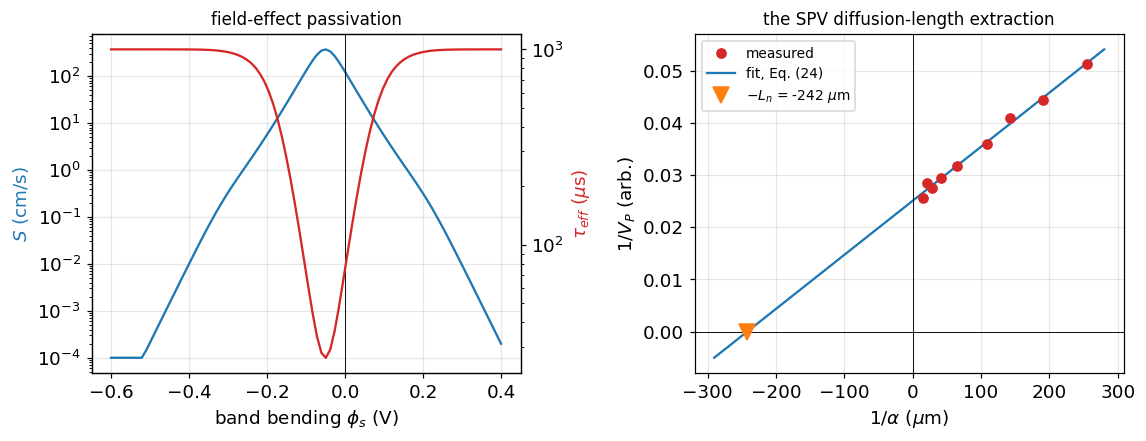

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10.6, 4.2))

ps = np.linspace(-0.6, 0.4, 90)
S = np.array([kp.surface_recombination_velocity(p, Nd, 'n',
                                                delta_n_cm3=1e14) for p in ps])
tau = kp.effective_lifetime_us(1000.0, S, 200.0)
ax[0].semilogy(ps, np.maximum(S, 1e-4), color='C0', label='$S$, Eq. (22)')
a2 = ax[0].twinx()
a2.semilogy(ps, tau, color='C3', label='$\\tau_{eff}$, Eq. (23)')
a2.set_ylabel('$\\tau_{eff}$ ($\\mu$s)', color='C3')
ax[0].axvline(0, color='k', lw=0.6)
ax[0].set_xlabel('band bending $\\phi_s$ (V)')
ax[0].set_ylabel('$S$ (cm/s)', color='C0')
ax[0].set_title('field-effect passivation', fontsize=11)
ax[0].grid(alpha=0.3)

wl = np.array([800, 830, 860, 900, 940, 980, 1000, 1020, 1040])
alpha = kp.alpha_silicon(wl)
Vp = kp.synthetic_spv_wavelength_scan(wl, L_n_um=250.0, noise_frac=0.02,
                                      seed=3)
L, Lerr, (m, b) = kp.fit_diffusion_length(alpha, Vp)

inv_a = 1e4 / alpha                                  # cm -> um
xx = np.linspace(-1.2 * L, inv_a.max() * 1.1, 50)
ax[1].plot(inv_a, 1 / Vp, 'o', color='C3', zorder=3, label='measured')
ax[1].plot(xx, m * xx * 1e-4 + b, color='C0', label='fit, Eq. (24)')
ax[1].axhline(0, color='k', lw=0.6); ax[1].axvline(0, color='k', lw=0.6)
ax[1].plot([-L], [0], 'v', color='C1', ms=10,
           label=f'$-L_n$ = {-L:.0f} $\\mu$m')
ax[1].set_xlabel('$1/\\alpha$ ($\\mu$m)'); ax[1].set_ylabel('$1/V_P$ (arb.)')
ax[1].set_title('the SPV diffusion-length extraction', fontsize=11)
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"S at flat band      : {kp.surface_recombination_velocity(0.0, Nd, 'n', delta_n_cm3=1e14):.4g} cm/s")
print(f"S at phi_s = +0.3 V : {kp.surface_recombination_velocity(0.3, Nd, 'n', delta_n_cm3=1e14):.4g} cm/s")
print(f"\nL_n = {L:.1f} +/- {Lerr:.1f} um   (true 250.0 um, "
      f"{100*Lerr/L:.1f}% uncertainty from 2% noise)")

Left: bending the bands by 300 mV in either direction drops $S$ by several
orders of magnitude and takes the effective lifetime with it. The peak sits
close to flat band, and the reason is that recombination through a state
needs **both** carriers to be available: bending the bands either way
starves one of them, and the numerator of Eq. (22) collapses much faster
than the denominator.

That gives two independent routes to a passivated surface — remove the
states, or bend the bands away from the peak — and they are the chemical
and field-effect mechanisms respectively [[19]](#ref19)[[20]](#ref20). A
lifetime measurement on its own reports only their combined effect. A
Kelvin probe sees the band bending directly, which is why the two
measurements are usually done together.

Right: 2% noise on the SPV becomes a 5% uncertainty on $L_n$, because
$L_n$ is a *negative x-intercept* — an extrapolation well outside the
measured data, just like the contact-resistance intercept in the TLM
notebook. Two consequences follow. Choose wavelengths whose $1/\alpha$
values straddle the expected $L_n$, or the extrapolation is longer than the
data. And treat the quoted $L_n$ with far more suspicion than the quality
of the fit invites.

## 14. Assumptions and limitations

The models here are deliberately simple. They assume:

- **one dimension and a uniform surface.** This is the big one. A
  macro-scale probe averages over millimetres, and Eq. (21) already shows
  that a patchy surface mimics a higher $D_{it}$. What the instrument
  reports is an area-weighted mean, not a typical value, and the two differ
  whenever the surface is inhomogeneous — which is most of the time on real
  films [[17]](#ref17).
- **Boltzmann statistics and complete ionisation**, so the model is not
  reliable at degenerate doping.
- **a uniform excess carrier density** across the space-charge region,
  rather than a depth-resolved generation profile [[13]](#ref13)[[14]](#ref14).
  The intensity axis of Sec. 11 is therefore an injection level, not a lamp
  setting; converting between them needs an optical model.
- **no surface dipoles.** Adsorbed layers shift the local vacuum level of
  Eq. (1) directly, by tens of millivolts in ambient air with humidity, and
  reversibly. This model has no term for it, and neither does any simple
  one [[9]](#ref9).
- **a model $D_{it}$ spectrum**, not a measured one, with
  energy-independent capture cross sections.
- **steady state.** Transient SPV, where the light is pulsed and the decay
  timed, needs the time-dependent problem and is not treated here.
- **an approximate $\alpha(\lambda)$** for Sec. 13, adequate for the shape
  of Eq. (24) but not for a certified diffusion length [[24]](#ref24).

They are sufficient to explain what a Kelvin probe reading contains, why
SPV isolates the surface term, and how a charge sweep separates the
contributions. Quantitative interface work needs a Fermi-Dirac solver, a
measured $D_{it}$ spectrum, an optical generation model, and an independent
handle on the surface non-uniformity.

**And one thing that is not an assumption but a definition:** every number
in this notebook follows the sign convention set in Eqs. (2) and (18). Any
comparison with the literature has to start by checking which convention
the other source used.

## Summary of equations

| # | Equation | Meaning | Source |
|---|---|---|---|
| (1) | $\Phi = E_{\text{vac}} - E_F$ | work function | [[1]](#ref1)[[10]](#ref10) |
| (2) | $V_{\text{CPD}} = (\Phi_{s} - \Phi_{p})/q$ | contact potential difference | [[1]](#ref1)[[3]](#ref3) |
| (3) | $C(t) = \varepsilon_0 A/(d_0 + d_1\sin\omega t)$ | the vibrating capacitor | [[2]](#ref2)[[4]](#ref4) |
| (4) | $i = (V_b + V_{\text{CPD}})\,dC/dt$ | DC turned into AC | [[2]](#ref2)[[4]](#ref4) |
| (5) | $V_{ptp} = k(V_b + V_{\text{CPD}})$ | the off-null line | [[4]](#ref4)[[5]](#ref5) |
| (6) | $V_{\text{CPD}} = c/k$ | the extraction | [[4]](#ref4)[[6]](#ref6) |
| (7) | $\Phi_{s} = \Phi_{p} + qV_{\text{CPD}}$ | calibration | [[3]](#ref3)[[6]](#ref6) |
| (8) | $\Phi_s = \chi + E_g/2 - q\phi_F$ | semiconductor work function | [[9]](#ref9)[[10]](#ref10) |
| (9) | $\phi_F = V_t\ln(N_{\text{dop}}/n_i)$ | the doping term | [[10]](#ref10) |
| (10) | $V_{\text{CPD}} = -(\Phi_{ms}/q + \phi_s + V_i)$ | **the master equation** | [[9]](#ref9)[[11]](#ref11) |
| (11) | $n_s = n_b e^{\phi_s/V_t}$, $p_s = p_b e^{-\phi_s/V_t}$ | surface carrier densities | [[9]](#ref9)[[10]](#ref10) |
| (12) | $Q_{sc} = -\text{sign}(\phi_s)\sqrt{2q\varepsilon_s V_t G}$ | space-charge density | [[10]](#ref10)[[7]](#ref7) |
| (13) | $\phi_s \approx qN^2/(2\varepsilon_s N_{\text{dop}})$ | depletion approximation | [[7]](#ref7) |
| (14) | $V_i = x_c Q_f/(K_i\varepsilon_0)$ | the dielectric term | [[9]](#ref9)[[11]](#ref11) |
| (15) | $Q_{it} = \int D^{d}_{it}f_p\,dE - \int D^{a}_{it}f_n\,dE$ | interface-state charge | [[9]](#ref9)[[13]](#ref13) |
| (16) | $f_p = \frac{(\sigma_n/\sigma_p)n_1 + p_s}{(\sigma_n/\sigma_p)(n_s+n_1)+(p_s+p_1)}$ | SRH occupancy | [[22]](#ref22)[[14]](#ref14) |
| (17) | $Q_f + Q_{sc} + Q_{it} = 0$ | charge neutrality | [[9]](#ref9)[[13]](#ref13) |
| (18) | $V_{\text{SPV}} = V_{\text{CPD,dark}} - V_{\text{CPD,light}}$ | **surface photovoltage** | [[9]](#ref9)[[7]](#ref7) |
| (19) | $V_{\text{SPV}} = -(\phi_s^{d} - \phi_s^{l})$ | everything else cancels | [[7]](#ref7)[[8]](#ref8) |
| (20) | $V_{\text{SPV}}(\Delta n\to\infty) = -\phi_s^{\text{dark}}$ | saturation gives band bending | [[7]](#ref7)[[9]](#ref9) |
| (21) | $\langle X\rangle = \int X(Q_f)\,\mathcal{N}(Q_{f0},\sigma_q)\,dQ_f$ | charge non-uniformity | [[17]](#ref17) |
| (22) | $S = \frac{1}{\Delta n}\int\frac{n_sp_s-n_i^2}{\ldots}dE$ | surface recombination velocity | [[22]](#ref22)[[19]](#ref19) |
| (23) | $1/\tau_{\text{eff}} = 1/\tau_b + 2S/W$ | effective lifetime | [[21]](#ref21)[[18]](#ref18) |
| (24) | $1/V_P = C(L_n + 1/\alpha)$ | SPV diffusion length | [[15]](#ref15)[[16]](#ref16) |

<a id="references"></a>

## References

These entries are the targets of the `[n]` markers used throughout the
notebook; each carries a DOI. The instrument items give the Kelvin method
and its noise behaviour, the review items the surface-photovoltage theory,
and the remainder the specific results used in the model.

**The Kelvin method and its instrumentation**

<a id="ref1"></a>
**[1]** Lord Kelvin (W. Thomson), *Contact electricity of metals*, Phil.
Mag. **46**, 82-120 (1898).
doi:[10.1080/14786449808621172](https://doi.org/10.1080/14786449808621172)

<a id="ref2"></a>
**[2]** W. A. Zisman, *A new method of measuring contact potential
differences in metals*, Rev. Sci. Instrum. **3**, 367-370 (1932).
doi:[10.1063/1.1748947](https://doi.org/10.1063/1.1748947)

<a id="ref3"></a>
**[3]** J. C. Rivière, *Contact potential difference measurements by the
Kelvin method*, Proc. Phys. Soc. B **70**, 676-686 (1957).
doi:[10.1088/0370-1301/70/7/305](https://doi.org/10.1088/0370-1301/70/7/305)

<a id="ref4"></a>
**[4]** I. D. Baikie, S. Mackenzie, P. J. Z. Estrup and J. A. Meyer,
*Noise and the Kelvin method*, Rev. Sci. Instrum. **62**, 1326-1332 (1991).
doi:[10.1063/1.1142494](https://doi.org/10.1063/1.1142494)

<a id="ref5"></a>
**[5]** I. D. Baikie, K. O. van der Werf, H. Oerbekke, J. Broeze and
A. van Silfhout, *Automatic Kelvin probe compatible with ultrahigh
vacuum*, Rev. Sci. Instrum. **60**, 930-934 (1989).
doi:[10.1063/1.1140346](https://doi.org/10.1063/1.1140346)

<a id="ref6"></a>
**[6]** I. D. Baikie and P. J. Estrup, *Low cost PC based scanning Kelvin
probe*, Rev. Sci. Instrum. **69**, 3902-3907 (1998).
doi:[10.1063/1.1149197](https://doi.org/10.1063/1.1149197)

**Surface voltage and photovoltage**

<a id="ref7"></a>
**[7]** D. K. Schroder, *Surface voltage and surface photovoltage: history,
theory and applications*, Meas. Sci. Technol. **12**, R16-R31 (2001).
doi:[10.1088/0957-0233/12/3/202](https://doi.org/10.1088/0957-0233/12/3/202)

<a id="ref8"></a>
**[8]** L. Kronik and Y. Shapira, *Surface photovoltage phenomena: theory,
experiment, and applications*, Surf. Sci. Rep. **37**, 1-206 (1999).
doi:[10.1016/S0167-5729(99)00002-3](https://doi.org/10.1016/S0167-5729(99)00002-3)

<a id="ref9"></a>
**[9]** R. S. Bonilla, *Modelling of Kelvin probe surface voltage and
photovoltage in dielectric-semiconductor interfaces*, Mater. Res. Express
**9**, 085901 (2022).
doi:[10.1088/2053-1591/ac84c8](https://doi.org/10.1088/2053-1591/ac84c8)

<a id="ref12"></a>
**[12]** W. H. Brattain and J. Bardeen, *Surface properties of germanium*,
Bell Syst. Tech. J. **32**, 1-41 (1953).
doi:[10.1002/j.1538-7305.1953.tb01420.x](https://doi.org/10.1002/j.1538-7305.1953.tb01420.x)

**Textbooks**

<a id="ref10"></a>
**[10]** S. M. Sze and K. K. Ng, *Physics of Semiconductor Devices*,
3rd ed., Wiley, Hoboken (2007).
doi:[10.1002/0470068329](https://doi.org/10.1002/0470068329)

<a id="ref11"></a>
**[11]** D. K. Schroder, *Semiconductor Material and Device
Characterization*, 3rd ed., Wiley, Hoboken (2006).
doi:[10.1002/0471749095](https://doi.org/10.1002/0471749095)

**Interface states, charge and recombination**

<a id="ref13"></a>
**[13]** R. B. M. Girisch, R. P. Mertens and R. F. De Keersmaecker,
*Determination of Si-SiO2 interface recombination parameters using a
gate-controlled point-junction diode under illumination*, IEEE Trans.
Electron Devices **35**, 203-222 (1988).
doi:[10.1109/16.2441](https://doi.org/10.1109/16.2441)

<a id="ref14"></a>
**[14]** A. G. Aberle, S. Glunz and W. Warta, *Impact of illumination level
and oxide parameters on Shockley-Read-Hall recombination at the Si-SiO2
interface*, J. Appl. Phys. **71**, 4422-4431 (1992).
doi:[10.1063/1.350782](https://doi.org/10.1063/1.350782)

<a id="ref22"></a>
**[22]** W. Shockley and W. T. Read, *Statistics of the recombinations of
holes and electrons*, Phys. Rev. **87**, 835-842 (1952).
doi:[10.1103/PhysRev.87.835](https://doi.org/10.1103/PhysRev.87.835)

<a id="ref17"></a>
**[17]** R. S. Bonilla, I. Al-Dhahir, M. Yu, P. Hamer and P. P. Altermatt,
*Charge fluctuations at the Si-SiO2 interface and its effect on surface
recombination in solar cells*, Sol. Energy Mater. Sol. Cells **215**,
110649 (2020).
doi:[10.1016/j.solmat.2020.110649](https://doi.org/10.1016/j.solmat.2020.110649)

<a id="ref18"></a>
**[18]** R. S. Bonilla and P. R. Wilshaw, *On the c-Si/SiO2 interface
recombination parameters from photo-conductance decay measurements*,
J. Appl. Phys. **121**, 135301 (2017).
doi:[10.1063/1.4979722](https://doi.org/10.1063/1.4979722)

<a id="ref19"></a>
**[19]** S. W. Glunz, D. Biro, S. Rein and W. Warta, *Field-effect
passivation of the SiO2-Si interface*, J. Appl. Phys. **86**, 683-691
(1999).
doi:[10.1063/1.370784](https://doi.org/10.1063/1.370784)

<a id="ref20"></a>
**[20]** G. Dingemans and W. M. M. Kessels, *Status and prospects of
Al2O3-based surface passivation schemes for silicon solar cells*, J. Vac.
Sci. Technol. A **30**, 040802 (2012).
doi:[10.1116/1.4728205](https://doi.org/10.1116/1.4728205)

<a id="ref21"></a>
**[21]** A. B. Sproul, *Dimensionless solution of the equation describing
the effect of surface recombination on carrier decay in semiconductors*,
J. Appl. Phys. **76**, 2851-2854 (1994).
doi:[10.1063/1.357521](https://doi.org/10.1063/1.357521)

<a id="ref23"></a>
**[23]** M. Yu, S. McNab, I. Al-Dhahir, C. E. Patrick, P. P. Altermatt and
R. S. Bonilla, *Extracting band-tail interface state densities from
measurements and modelling of space charge layer resistance*, Sol. Energy
Mater. Sol. Cells **231**, 111307 (2021).
doi:[10.1016/j.solmat.2021.111307](https://doi.org/10.1016/j.solmat.2021.111307)

**The SPV diffusion-length method**

<a id="ref15"></a>
**[15]** A. M. Goodman, *A method for the measurement of short minority
carrier diffusion lengths in semiconductors*, J. Appl. Phys. **32**,
2550-2552 (1961).
doi:[10.1063/1.1728351](https://doi.org/10.1063/1.1728351)

<a id="ref16"></a>
**[16]** E. O. Johnson, *Measurement of minority carrier lifetimes with the
surface photovoltage*, J. Appl. Phys. **28**, 1349-1353 (1957).
doi:[10.1063/1.1722650](https://doi.org/10.1063/1.1722650)

<a id="ref24"></a>
**[24]** E. S. Nartowitz and A. M. Goodman, *Evaluation of silicon optical
absorption data for use in minority-carrier-diffusion-length measurements
by the SPV method*, J. Electrochem. Soc. **132**, 2992-2997 (1985).
doi:[10.1149/1.2113709](https://doi.org/10.1149/1.2113709)